In [ ]:
from pathlib import Path
import wfdb
import numpy as np

#subject_dir = Path(r"/home/charlotte/Documents/Tesi/Motoneuron_Synergies_Driven_Gesture_Prediction/glove_sample_subj_01_trial_01")
subject_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_01")
# Record WFDB: .hea (header) and .dat (dati).
hea_files = sorted(subject_dir.glob("*.hea"))
print("File .hea trovati:")
for f in hea_files:
    print(f.name)

# Choose the first .hea file (assuming there's only one record per trial)
record_base = hea_files[0].with_suffix("")  

# Read record: wfdb load automatically the .dat file
rec = wfdb.rdrecord(str(record_base))

print("\nName Angles Glove:")
for i, name in enumerate(rec.sig_name):
    print(i, name)

data = rec.p_signal
print("\nShape dati:", data.shape)
print("Sampling Frequency (I think here there is an error in the file, paper explicitly says 200 Hz):", rec.fs)

File .hea trovati:
hdkw_kin_exp03_subj01_1_glove.hea

Name Angles Glove:
0 TN
1 TF
2 T&I
3 IN
4 IF
5 I&M
6 MN
7 MF
8 M&R
9 RN
10 RF
11 R&P
12 PN
13 PF

Shape dati: (37400, 14)
Sampling Frequency: 2000


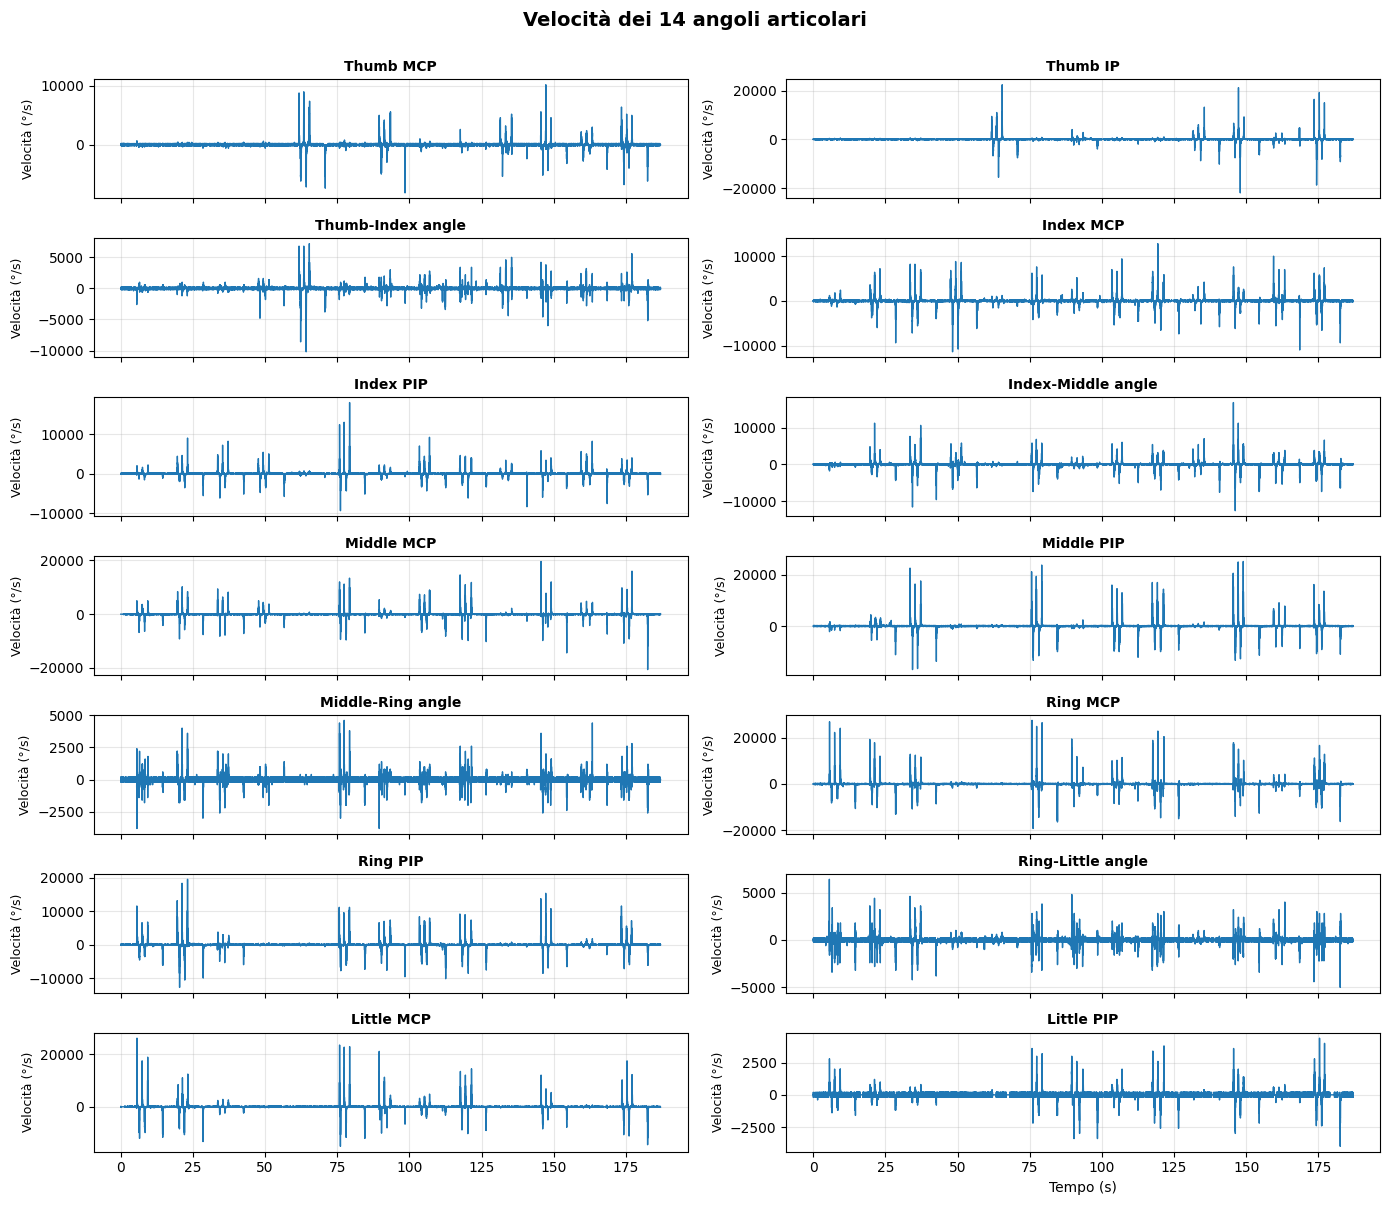

Durata totale: 186.99 secondi
Numero campioni velocità: 37399


In [4]:
import matplotlib.pyplot as plt

# Calcolo velocità (derivata degli angoli)
fs = 200  # 200 Hz
dt = 1 / fs
velocities = np.diff(data, axis=0) / dt

# Tempo in secondi
time = np.arange(velocities.shape[0]) / fs

# Mappatura canali
channel_names = [
    "Thumb MCP", "Thumb IP", "Thumb-Index angle",
    "Index MCP", "Index PIP", "Index-Middle angle",
    "Middle MCP", "Middle PIP", "Middle-Ring angle",
    "Ring MCP", "Ring PIP", "Ring-Little angle",
    "Little MCP", "Little PIP"
]

# Plot: velocità di ogni angolo
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(14):
    axes[ch].plot(time, velocities[:, ch], linewidth=1)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Velocità dei 14 angoli articolari', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"Durata totale: {time[-1]:.2f} secondi")
print(f"Numero campioni velocità: {velocities.shape[0]}")

## Define the Rig in Unity in order to choose wheter preprocessing the angular information

In [5]:
import pandas as pd

df = pd.DataFrame(data, columns=channel_names)
df.to_csv("glove_data.csv", index=False)

In [8]:
from pathlib import Path
import wfdb
import numpy as np
import pandas as pd

# === INPUT ===
record_base = r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_01"   # senza .hea/.dat
fs_expected = 200  # per il glove, dal paper/dataset description

channel_names = [
    "Thumb_MCP", "Thumb_IP", "Thumb_Index_abd",
    "Index_MCP", "Index_PIP", "Index_Middle_abd",
    "Middle_MCP", "Middle_PIP", "Middle_Ring_abd",
    "Ring_MCP", "Ring_PIP", "Ring_Little_abd",
    "Little_MCP", "Little_PIP"
]

# Range pratici per Unity
flexion_channels = {
    "Thumb_MCP": 60.0,
    "Thumb_IP": 80.0,
    "Index_MCP": 75.0,
    "Index_PIP": 95.0,
    "Middle_MCP": 75.0,
    "Middle_PIP": 100.0,
    "Ring_MCP": 75.0,
    "Ring_PIP": 100.0,
    "Little_MCP": 75.0,
    "Little_PIP": 95.0,
}

abduction_channels = {
    "Thumb_Index_abd": 30.0,
    "Index_Middle_abd": 20.0,
    "Middle_Ring_abd": 20.0,
    "Ring_Little_abd": 25.0,
}

# Segni da regolare poi in Unity se qualche dito gira al contrario
sign_map = {
    "Thumb_MCP": 1.0,
    "Thumb_IP": 1.0,
    "Thumb_Index_abd": 1.0,
    "Index_MCP": 1.0,
    "Index_PIP": 1.0,
    "Index_Middle_abd": 1.0,
    "Middle_MCP": 1.0,
    "Middle_PIP": 1.0,
    "Middle_Ring_abd": 1.0,
    "Ring_MCP": 1.0,
    "Ring_PIP": 1.0,
    "Ring_Little_abd": 1.0,
    "Little_MCP": 1.0,
    "Little_PIP": 1.0,
}

# === LOAD WFDB ===
#rec = wfdb.rdrecord(record_base)
#data = rec.p_signal.astype(np.float64)

if data.shape[1] != 14:
    raise ValueError(f"Expected 14 glove channels, found {data.shape[1]}")

n_samples = data.shape[0]
time_s = np.arange(n_samples) / fs_expected

raw_df = pd.DataFrame(data, columns=channel_names)
raw_df.insert(0, "time_s", time_s)

# === MIN-MAX NORMALIZATION PER CHANNEL ===
mins = raw_df[channel_names].min(axis=0)
maxs = raw_df[channel_names].max(axis=0)
ranges = (maxs - mins).replace(0, 1.0)

norm_df = raw_df.copy()
norm_df[channel_names] = (raw_df[channel_names] - mins) / ranges

# clamp safety
norm_df[channel_names] = norm_df[channel_names].clip(0.0, 1.0)

# === UNITY DEGREES CSV ===
unity_df = pd.DataFrame()
unity_df["time_s"] = time_s

for ch in channel_names:
    vals = norm_df[ch].values

    if ch in flexion_channels:
        deg = vals * flexion_channels[ch]
    elif ch in abduction_channels:
        deg = (vals - 0.5) * abduction_channels[ch]
    else:
        deg = vals * 90.0

    deg = sign_map[ch] * deg
    unity_df[ch] = deg

# === CALIBRATION TABLE ===
calib_rows = []
for ch in channel_names:
    calib_rows.append({
        "channel": ch,
        "raw_min": float(mins[ch]),
        "raw_max": float(maxs[ch]),
        "range": float(ranges[ch]),
        "unity_mapping": (
            f"norm*{flexion_channels[ch]:.1f}"
            if ch in flexion_channels
            else f"(norm-0.5)*{abduction_channels[ch]:.1f}"
        ),
        "sign": sign_map[ch]
    })

calib_df = pd.DataFrame(calib_rows)

# === SAVE ===
out_dir = Path(record_base).parent
raw_path = out_dir / "glove_raw.csv"
norm_path = out_dir / "glove_norm01.csv"
unity_path = out_dir / "glove_unity_deg.csv"
calib_path = out_dir / "glove_calibration.csv"

raw_df.to_csv(raw_path, index=False)
norm_df.to_csv(norm_path, index=False)
unity_df.to_csv(unity_path, index=False)
calib_df.to_csv(calib_path, index=False)

print(f"Saved: {raw_path}")
print(f"Saved: {norm_path}")
print(f"Saved: {unity_path}")
print(f"Saved: {calib_path}")
print("\nHead of normalized data:")
print(norm_df.head())
print("\nCalibration table:")
print(calib_df)

Saved: C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_raw.csv
Saved: C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_norm01.csv
Saved: C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_unity_deg.csv
Saved: C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_calibration.csv

Head of normalized data:
   time_s  Thumb_MCP  Thumb_IP  Thumb_Index_abd  Index_MCP  Index_PIP  \
0   0.000   0.096939  0.231986         0.257353   0.320236   0.261168   
1   0.005   0.096939  0.231986         0.257353   0.320236   0.261168   
2   0.010   0.096939  0.231986         0.257353   0.320236   0.261168   
3   0.015   0.096939  0.231986         0.257353   0.320236   0.261168   
4   0.020   0.099490  0.230228         0.257353   0.320236   0.261168   

  